In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


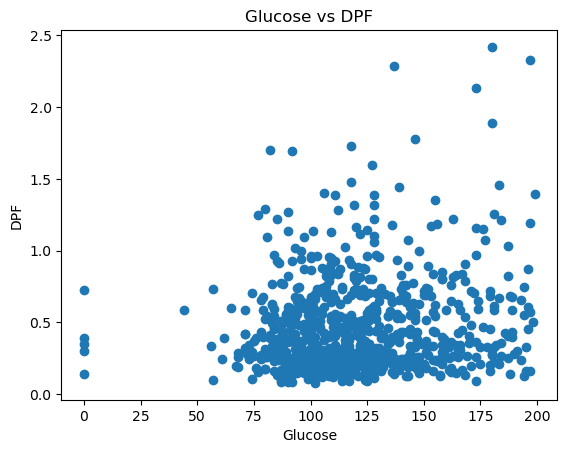

In [7]:
plt.scatter(df["Glucose"], df["DiabetesPedigreeFunction"])

plt.xlabel("Glucose")
plt.ylabel("DPF")

plt.title("Glucose vs DPF")

plt.show()


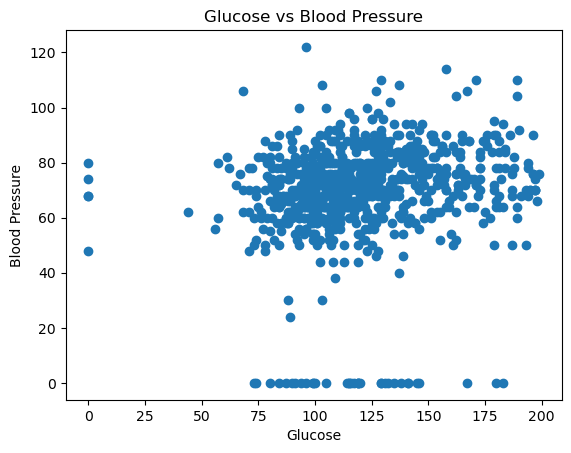

In [8]:
plt.scatter(df["Glucose"], df["BloodPressure"])

plt.xlabel("Glucose")
plt.ylabel("Blood Pressure")

plt.title("Glucose vs Blood Pressure")

plt.show()

In [11]:
X = df[["Glucose","Pregnancies","BMI"]]
y = df["Outcome"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)


In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [15]:
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(predictions)

[0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 0 1 1
 0 0 1 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0
 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0
 0 1 0 0 0 0]


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)


Accuracy: 0.7727272727272727


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)


[[84 15]
 [20 35]]


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.81      0.85      0.83        99
           1       0.70      0.64      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.75       154
weighted avg       0.77      0.77      0.77       154



In [47]:
new_patient1 = pd.DataFrame({
    "Glucose":[160],
    "Pregnancies":[7],
    "BMI":[35.5]
})
model.predict(new_patient1)

array([1], dtype=int64)

In [49]:
if model.predict(new_patient1) == 1:
    print("Cancer")
else:
    print("Healthy")


Cancer


In [51]:
new_patient2 = pd.DataFrame({
    "Glucose":[88],
    "Pregnancies":[5],
    "BMI":[27.6]
})
model.predict(new_patient2)

array([0], dtype=int64)

In [53]:
if model.predict(new_patient2) == 1:
    print("Cancer")
else:
    print("Healthy")


Healthy


In [67]:
model.predict_proba(new_patient1)


array([[0.2387853, 0.7612147]])

In [69]:
model.predict_proba(new_patient2)


array([[0.89980034, 0.10019966]])

In [73]:
import numpy as np
y_prob = model.predict_proba(X_test)
np.set_printoptions(suppress=True)
print(y_prob)


[[0.76340805 0.23659195]
 [0.73873949 0.26126051]
 [0.8330462  0.1669538 ]
 [0.81137783 0.18862217]
 [0.53501959 0.46498041]
 [0.66291498 0.33708502]
 [0.97995104 0.02004896]
 [0.78312258 0.21687742]
 [0.44499171 0.55500829]
 [0.42044772 0.57955228]
 [0.69519396 0.30480604]
 [0.15703782 0.84296218]
 [0.50385379 0.49614621]
 [0.80149933 0.19850067]
 [0.92341363 0.07658637]
 [0.71880091 0.28119909]
 [0.84842911 0.15157089]
 [0.88408466 0.11591534]
 [0.28188022 0.71811978]
 [0.43397633 0.56602367]
 [0.82533952 0.17466048]
 [0.90826527 0.09173473]
 [0.45522841 0.54477159]
 [0.87196702 0.12803298]
 [0.37233083 0.62766917]
 [0.12314197 0.87685803]
 [0.83205464 0.16794536]
 [0.95248164 0.04751836]
 [0.62393412 0.37606588]
 [0.89633902 0.10366098]
 [0.12551693 0.87448307]
 [0.35646074 0.64353926]
 [0.15054186 0.84945814]
 [0.43598577 0.56401423]
 [0.6271201  0.3728799 ]
 [0.26502868 0.73497132]
 [0.15209225 0.84790775]
 [0.84117354 0.15882646]
 [0.58286811 0.41713189]
 [0.49564567 0.50435433]


In [75]:
y_prob_rounded = np.round(y_prob, 3)

print(y_prob_rounded)

[[0.763 0.237]
 [0.739 0.261]
 [0.833 0.167]
 [0.811 0.189]
 [0.535 0.465]
 [0.663 0.337]
 [0.98  0.02 ]
 [0.783 0.217]
 [0.445 0.555]
 [0.42  0.58 ]
 [0.695 0.305]
 [0.157 0.843]
 [0.504 0.496]
 [0.801 0.199]
 [0.923 0.077]
 [0.719 0.281]
 [0.848 0.152]
 [0.884 0.116]
 [0.282 0.718]
 [0.434 0.566]
 [0.825 0.175]
 [0.908 0.092]
 [0.455 0.545]
 [0.872 0.128]
 [0.372 0.628]
 [0.123 0.877]
 [0.832 0.168]
 [0.952 0.048]
 [0.624 0.376]
 [0.896 0.104]
 [0.126 0.874]
 [0.356 0.644]
 [0.151 0.849]
 [0.436 0.564]
 [0.627 0.373]
 [0.265 0.735]
 [0.152 0.848]
 [0.841 0.159]
 [0.583 0.417]
 [0.496 0.504]
 [0.917 0.083]
 [0.766 0.234]
 [0.679 0.321]
 [0.59  0.41 ]
 [0.932 0.068]
 [0.435 0.565]
 [0.669 0.331]
 [0.744 0.256]
 [0.799 0.201]
 [0.152 0.848]
 [0.915 0.085]
 [0.392 0.608]
 [0.194 0.806]
 [0.712 0.288]
 [0.83  0.17 ]
 [0.938 0.062]
 [0.415 0.585]
 [0.994 0.006]
 [0.608 0.392]
 [0.278 0.722]
 [0.309 0.691]
 [0.647 0.353]
 [0.804 0.196]
 [0.77  0.23 ]
 [0.881 0.119]
 [0.373 0.627]
 [0.942 0.

In [77]:
model.coef_

array([[0.03348569, 0.12183583, 0.08857181]])

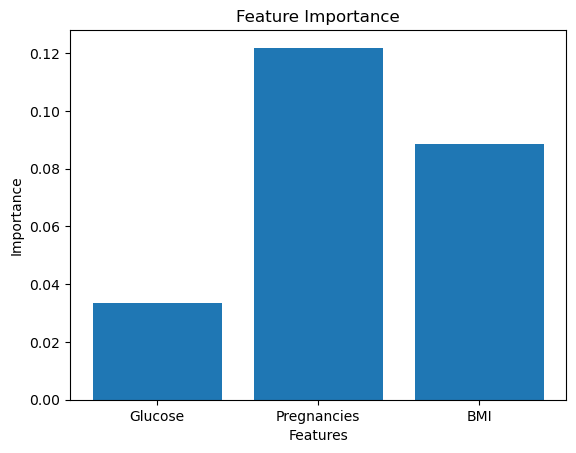

In [79]:
features = ["Glucose","Pregnancies","BMI"]

importance = model.coef_[0]

plt.bar(features, importance)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance")

plt.show()
